In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#pd.set_option('display.max_rows', None)
print("All libraries installed and imported successfully!")

All libraries installed and imported successfully!


In [7]:
import sys
print(sys.executable)


c:\Users\vachippa\Desktop\Sales data Anlysis\.venv\Scripts\python.exe


In [10]:
data = pd.read_csv(r'C:\Users\vachippa\Downloads\VideoGamesSales.csv')


In [11]:
data.head()

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,NA_Sales,Global_Sales,NA_Profit,Global_Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,$41.49,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,$29.08,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,$15.85,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,$15.75,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,$11.27,31.37,3.381,9.411


In [12]:
data.shape

(5909, 15)

In [13]:
data[data.duplicated()]

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,NA_Sales,Global_Sales,NA_Profit,Global_Profit
9,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
10,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
11,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
12,9,New Super Mario Bros. Wii,Wii,2010,Sep,Platform,Nintendo,USA,Fairfield,Ohio,East,$14.59,28.62,4.377,8.586
64,60,Super Mario 64,DS,2010,Dec,Platform,Nintendo,United States,Seattle,Washington,West,5.08,10.42,1.524,3.126
65,60,Super Mario 64,DS,2010,Dec,Platform,Nintendo,United States,Seattle,Washington,West,5.08,10.42,1.524,3.126
66,60,Super Mario 64,DS,2010,Dec,Platform,Nintendo,United States,Seattle,Washington,West,5.08,10.42,1.524,3.126
380,373,Donkey Kong Country 3: Dixie Kong's Double Tro...,SNES,2010,Jan,Platform,Nintendo,United States,Lancaster,Ohio,East,1.17,3.51,0.351,1.053
381,373,Donkey Kong Country 3: Dixie Kong's Double Tro...,SNES,2010,Jan,Platform,Nintendo,United States,Lancaster,Ohio,East,1.17,3.51,0.351,1.053
382,373,Donkey Kong Country 3: Dixie Kong's Double Tro...,SNES,2010,Jan,Platform,Nintendo,United States,Lancaster,Ohio,East,1.17,3.51,0.351,1.053


In [14]:
## Remove duplicate rows
data = data.drop_duplicates()

In [15]:
data.info()

<class 'pandas.DataFrame'>
Index: 5893 entries, 0 to 5908
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           5893 non-null   int64  
 1   Name           5893 non-null   str    
 2   Platform       5893 non-null   str    
 3   Year           5893 non-null   int64  
 4   Month          5893 non-null   str    
 5   Genre          5893 non-null   str    
 6   Publisher      5881 non-null   str    
 7   Country        5893 non-null   str    
 8   City           5893 non-null   str    
 9   State          5893 non-null   str    
 10  Region         5866 non-null   str    
 11  NA_Sales       5893 non-null   str    
 12  Global_Sales   5893 non-null   float64
 13  NA_Profit      5893 non-null   float64
 14  Global_Profit  5893 non-null   float64
dtypes: float64(3), int64(2), str(10)
memory usage: 736.6 KB


In [16]:
## Fill NaN value with 'Not Available' is Publisher column
data['Publisher'] = data['Publisher'].fillna('Not Available')

## Fill NaN value with 'North' is Region column
data['Region'] = data['Region'].fillna('North')

In [17]:
data.shape

(5893, 15)

In [18]:
## Remove '$' from NA_Sales column
data['NA_Sales'] = data['NA_Sales'].replace('[$]', '', regex=True)

In [19]:
## Convert data type of NA_Sales column
data['NA_Sales'] = pd.to_numeric(data['NA_Sales'], errors='coerce')
data

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,NA_Sales,Global_Sales,NA_Profit,Global_Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,41.49,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,29.08,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,15.85,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,15.75,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,11.27,31.37,3.381,9.411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,5890,Crazy Taxi: Catch a Ride,GBA,2017,Sep,Racing,THQ,Australia,Sydney,New South Wales,West,0.21,0.30,0.063,0.090
5905,5891,MySims Party,DS,2017,Oct,Simulation,Electronic Arts,Australia,Sydney,New South Wales,West,0.15,0.30,0.045,0.090
5906,5892,Harry Potter and the Order of the Phoenix,X360,2017,Nov,Action,Electronic Arts,Australia,Sydney,New South Wales,West,0.24,0.30,0.072,0.090
5907,5893,Skylanders: SuperChargers,PS4,2017,Dec,Action,Activision,Australia,Sydney,New South Wales,West,0.17,0.30,0.051,0.090


In [20]:
## Average Sales
average_sales = data['NA_Sales'].mean()
average_sales

np.float64(0.6509893093500764)

In [21]:
data['Country'].value_counts()

Country
Australia        3108
United States    2755
USA                30
Name: count, dtype: int64

In [22]:
data['Country'] = data['Country'].replace({'USA' : 'United States'})

<Axes: >

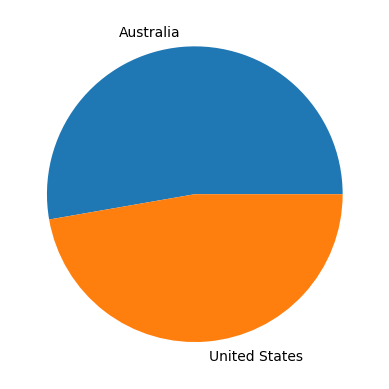

In [23]:
data['Country'].value_counts().plot(kind='pie')

In [24]:
data = data.rename(columns={'NA_Sales': 'National Sales', 'Global_Sales': 'Global Sales', 'NA_Profit':'National Profit', 'Global_Profit': 'Global Profit' })
data

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National Profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,41.49,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,29.08,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,15.85,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,15.75,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,11.27,31.37,3.381,9.411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,5890,Crazy Taxi: Catch a Ride,GBA,2017,Sep,Racing,THQ,Australia,Sydney,New South Wales,West,0.21,0.30,0.063,0.090
5905,5891,MySims Party,DS,2017,Oct,Simulation,Electronic Arts,Australia,Sydney,New South Wales,West,0.15,0.30,0.045,0.090
5906,5892,Harry Potter and the Order of the Phoenix,X360,2017,Nov,Action,Electronic Arts,Australia,Sydney,New South Wales,West,0.24,0.30,0.072,0.090
5907,5893,Skylanders: SuperChargers,PS4,2017,Dec,Action,Activision,Australia,Sydney,New South Wales,West,0.17,0.30,0.051,0.090


In [25]:
sales_cap = data['National Sales'].quantile(0.95)
data['National Sales'] = np.where(data['National Sales'] > sales_cap, sales_cap, data['Global Sales'])

In [26]:
data

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National Profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,2.07,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,2.07,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,2.07,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,2.07,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,2.07,31.37,3.381,9.411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,5890,Crazy Taxi: Catch a Ride,GBA,2017,Sep,Racing,THQ,Australia,Sydney,New South Wales,West,0.30,0.30,0.063,0.090
5905,5891,MySims Party,DS,2017,Oct,Simulation,Electronic Arts,Australia,Sydney,New South Wales,West,0.30,0.30,0.045,0.090
5906,5892,Harry Potter and the Order of the Phoenix,X360,2017,Nov,Action,Electronic Arts,Australia,Sydney,New South Wales,West,0.30,0.30,0.072,0.090
5907,5893,Skylanders: SuperChargers,PS4,2017,Dec,Action,Activision,Australia,Sydney,New South Wales,West,0.30,0.30,0.051,0.090


In [27]:
## Create a bar plot for Region and country wise National Sales

national_sales_data = data.groupby(['Country','Region'])['National Sales'].sum().reset_index(name = 'Sales').sort_values(by = 'Sales', ascending = False)
national_sales_data

,Country,Region,Sales
9,United States,West,1458.82
4,Australia,West,1348.25
6,United States,East,1290.45
5,United States,Central,1057.62
8,United States,South,733.06
2,Australia,Other,57.51
7,United States,North,34.81
3,Australia,South,31.35
1,Australia,North,28.28
0,Australia,East,2.86


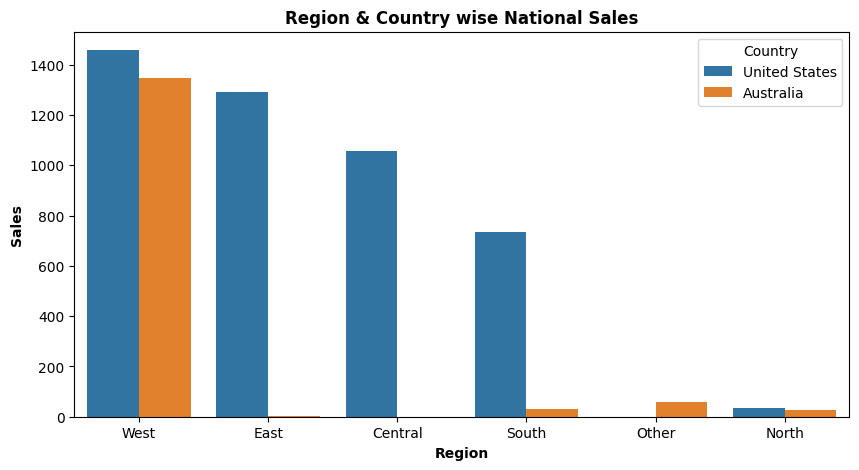

In [28]:
plt.figure(figsize =(10, 5))
sns.barplot(data =national_sales_data, x='Region', y='Sales', hue='Country')
plt.title('Region & Country wise National Sales', fontweight ='bold')
plt.xlabel('Region', fontweight ='bold')
plt.ylabel('Sales', fontweight ='bold')
plt.show()

In [29]:
data.head(2)

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National Profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,2.07,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,2.07,40.24,8.724,12.072


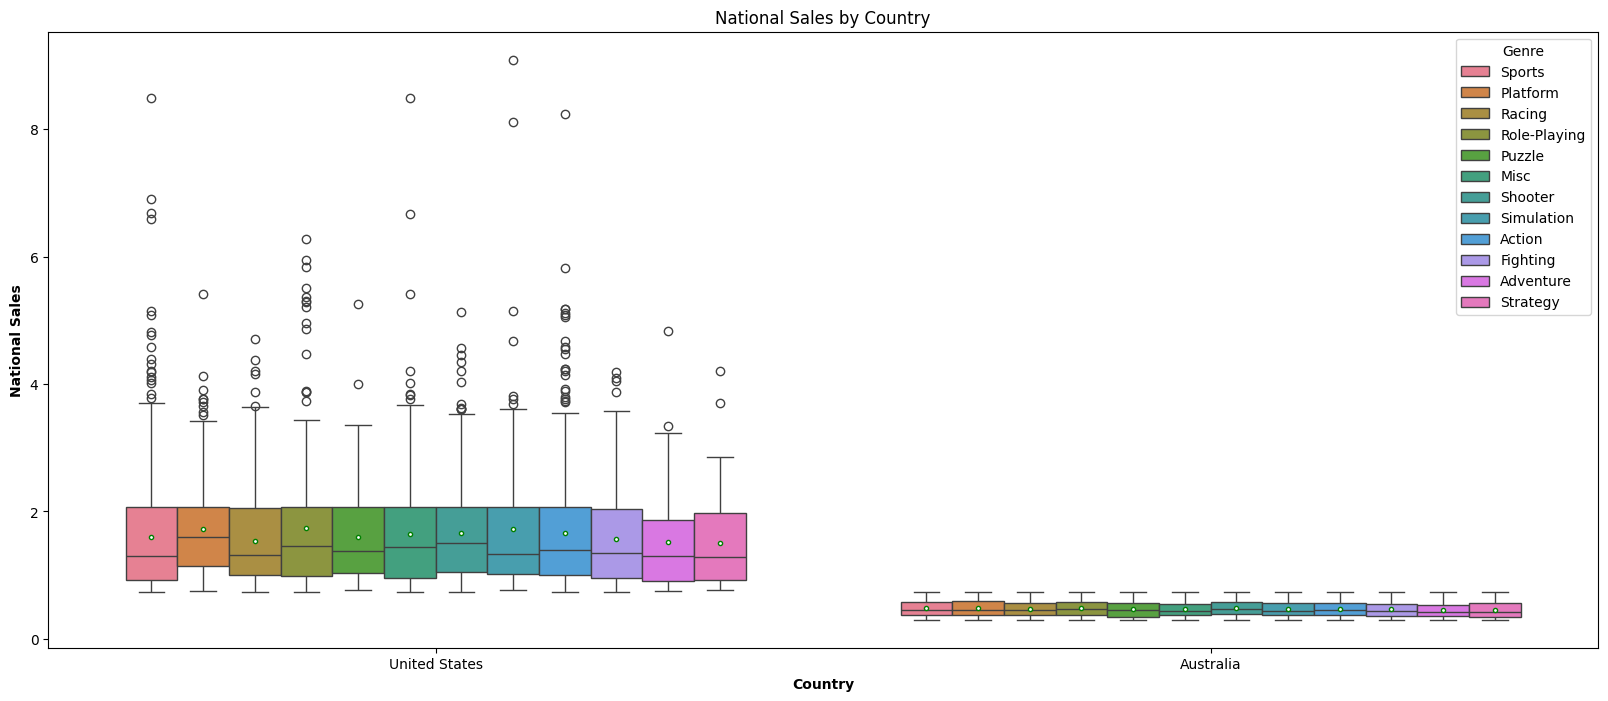

In [30]:
## Box Plot
plt.figure(figsize =(20, 8))
sns.boxplot(x='Country', y='National Sales', data=data, hue='Genre', showmeans= True, meanprops ={"marker": "o","markerfacecolor":"white", 
                                                                                 "markersize":"3","markeredgecolor":"green"})
plt.title('National Sales by Country')
plt.xlabel('Country', fontweight ='bold')
plt.ylabel('National Sales', fontweight ='bold')
plt.show()

In [31]:
data.head(2)

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National Profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,2.07,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,2.07,40.24,8.724,12.072


In [32]:
## Pie chart
sales =data.groupby(['Country'])[['National Sales','Global Sales']].sum().reset_index()
country=sales['Country']
national_sales = sales['National Sales']
global_sales = sales['Global Sales']

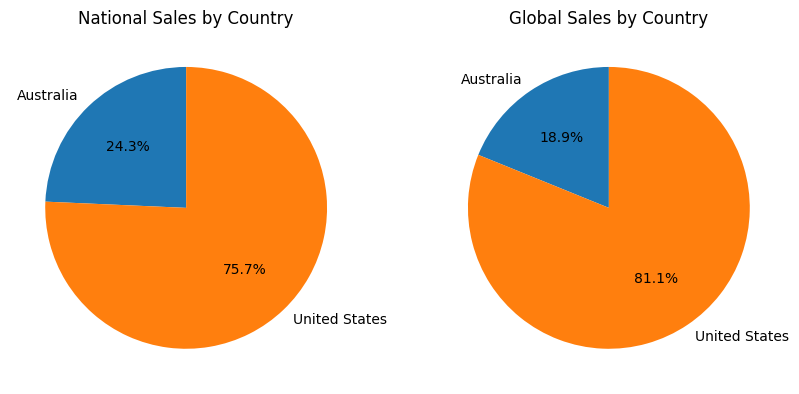

In [33]:
fig, axs = plt.subplots(1,2, figsize=(10, 7))
axs[0].pie(national_sales, labels=country, autopct='%1.1f%%', startangle=90)
axs[0].set_title('National Sales by Country')

axs[1].pie(global_sales, labels=country, autopct='%1.1f%%', startangle=90)
axs[1].set_title('Global Sales by Country')

plt.show()

In [34]:
data.head(2)

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National Profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,2.07,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,2.07,40.24,8.724,12.072


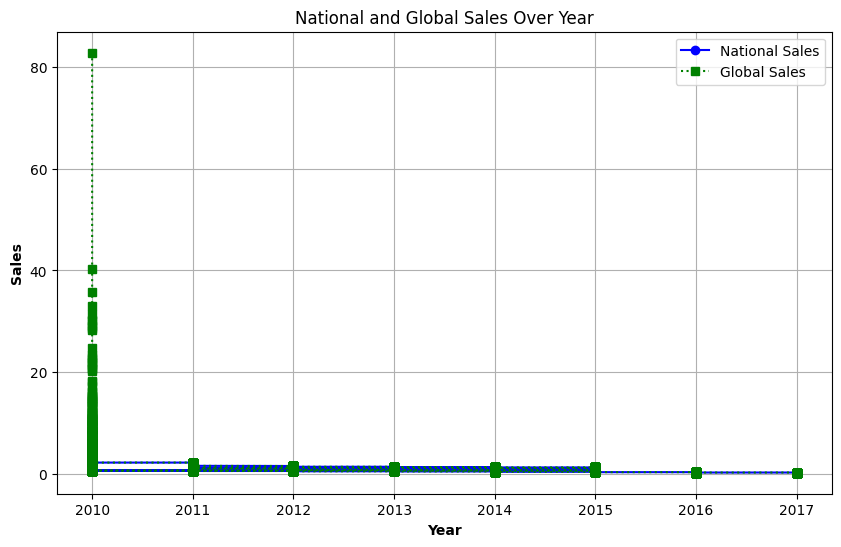

In [35]:
# Line chart
plt.figure(figsize=(10, 6))

# Line for National Sales
plt.plot(data['Year'], data['National Sales'], marker='o', linestyle='solid', color='b', label='National Sales')

# Line for Global Sales
plt.plot(data['Year'], data['Global Sales'], marker='s', linestyle='dotted', color='g', label='Global Sales')

plt.title('National and Global Sales Over Year')
plt.xlabel('Year', fontweight ='bold')
plt.ylabel('Sales', fontweight ='bold')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
data.to_csv("cleaned_sales.csv", index=False)
